# Travel Reimbursement Approval Agent —

This notebook implements Travel Reimbursement Approval using:
- Python
- direct OpenCode Go API via `openai`
- JSON / CSV / form-style claim intake
- policy grounding
- four deterministic tools
- OpenCode Go reasoning and structured output
- Manual Review guardrails
- a results dashboard


## Install dependencies


In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "openai", "pandas", "matplotlib", "pydantic"
])

print("Dependencies installed.")


Dependencies installed.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## OpenCode Go API configuration



In [2]:
import os
import json
from io import StringIO
from getpass import getpass
from typing import Any, Dict, List, Literal

import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from openai import OpenAI

# OpenCode Go API key.
# Get the key through OpenCode Go and keep it out of source control.
if not os.getenv("OPENCODE_API_KEY"):
    os.environ["OPENCODE_API_KEY"] = getpass(
        "Enter your OpenCode Go API key: "
    )

OPENCODE_API_KEY = os.getenv("OPENCODE_API_KEY")

if not OPENCODE_API_KEY:
    raise RuntimeError("OPENCODE_API_KEY is not set.")

# OpenCode Go currently exposes GLM-5.3-Flash through
# an OpenAI-compatible Chat Completions endpoint.
OPENCODE_BASE_URL = "https://opencode.ai/zen/go/v1"
MODEL = os.getenv("OPENCODE_MODEL", "glm-5.3-flash")

client = OpenAI(
    api_key=OPENCODE_API_KEY,
    base_url=OPENCODE_BASE_URL,
)

print("OpenCode Go client initialized.")
print("Base URL:", OPENCODE_BASE_URL)
print("Model:", MODEL)


OpenCode Go client initialized.
Base URL: https://opencode.ai/zen/go/v1
Model: glm-5.3-flash


## Connectivity test




In [3]:

try:
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": "Respond with exactly: OpenCode Go API connection successful",
            }
        ],
        temperature=0,
    )

    print(response.choices[0].message.content)
    print("OpenCode Go connection successful.")

except Exception as exc:
    print(f"OpenCode Go connection test failed: {type(exc).__name__}: {exc}")
    raise


OpenCode Go API connection successful
OpenCode Go connection successful.


## Policy grounding



In [5]:
POLICY = {
    "POL-CAT-01": {
        "title": "Eligible categories",
        "text": "Reimbursable when incurred for a documented business purpose: airfare (economy only), lodging, meals subject to per-diem limits, ground transport, and conference/registration fees.",
    },
    "POL-CAT-02": {
        "title": "Ineligible items",
        "text": "Alcohol and minibar charges; spa, gym, personal entertainment; in-room movies, personal shopping, gifts; traffic fines, penalties, late fees; and personal non-business expenses are never reimbursable.",
    },
    "POL-PD-01": {
        "title": "Meals limit",
        "text": "Meals maximum is $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed.",
    },
    "POL-PD-02": {
        "title": "Lodging limit",
        "text": "Lodging maximum is $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed.",
    },
    "POL-PD-03": {
        "title": "Ground transport limit",
        "text": "Ground transport maximum is $50 per day. Amounts above the cap are deducted.",
    },
    "POL-AIR-01": {
        "title": "Airfare class",
        "text": "Only economy airfare is reimbursable. Business/first-class fares are a policy exception and must be routed to Manual Review.",
    },
    "POL-RCT-01": {
        "title": "Receipt required",
        "text": "Any single line item greater than $25 requires an attached, itemized receipt. Airfare and lodging always require a receipt regardless of amount.",
    },
    "POL-RCT-02": {
        "title": "Missing receipt",
        "text": "If a required receipt is missing, route the claim to Manual Review rather than silently rejecting the item.",
    },
    "POL-APR-01": {
        "title": "Auto-approve tier",
        "text": "Total reimbursable amount <= $500 may be auto-approved if fully compliant.",
    },
    "POL-APR-02": {
        "title": "Manager tier",
        "text": "Total reimbursable amount > $500 and <= $2,000 is approvable when fully compliant.",
    },
    "POL-APR-03": {
        "title": "Director / Manual Review tier",
        "text": "Total reimbursable amount > $2,000 exceeds the agent's authority and must be routed to Manual Review.",
    },
    "POL-TIME-01": {
        "title": "Submission window",
        "text": "Claims must be submitted within 30 days of the expense date. Late claims are routed to Manual Review.",
    },
}


## Claim intake

The five claims below are the supplied Appendix B claims. The helpers also support JSON, CSV, and form-style input.


In [6]:
claims_json = json.dumps([
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "trip_start": "2026-06-10",
        "trip_end": "2026-06-12",
        "submitted": "2026-06-20",
        "business_purpose": "Attend 2-day industry conference (business)",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": True, "nights": 2},
            {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": True, "days": 3},
            {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "trip_start": "2026-06-14",
        "trip_end": "2026-06-15",
        "submitted": "2026-06-25",
        "business_purpose": "Weekend hotel stay",
        "items": [
            {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": True},
            {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "trip_start": "2026-06-08",
        "trip_end": "2026-06-10",
        "submitted": "2026-06-22",
        "business_purpose": "Client site visit (business)",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": True, "nights": 2},
            {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": True, "days": 2},
        ],
    },
    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "trip_start": "2026-06-16",
        "trip_end": "2026-06-18",
        "submitted": "2026-06-28",
        "business_purpose": "International vendor negotiation (business)",
        "items": [
            {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": True, "airfare_class": "business"},
            {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": False, "nights": 3},
        ],
    },
    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "trip_start": "2026-06-11",
        "trip_end": "2026-06-11",
        "submitted": "2026-06-24",
        "business_purpose": "Client dinner / business development",
        "items": [
            {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": False},
        ],
    },
], indent=2)

def claims_from_json(text):
    data = json.loads(text)
    if not isinstance(data, list):
        raise ValueError("JSON input must be a list.")
    return data

def claims_from_csv(text):
    df = pd.read_csv(StringIO(text))
    claims = []
    for cid, group in df.groupby("claim_id", sort=False):
        first = group.iloc[0]
        items = []
        for _, row in group.iterrows():
            item = {
                "category": row["category"],
                "description": row["description"],
                "amount": float(row["amount"]),
                "receipt_attached": str(row["receipt_attached"]).lower() in {"true", "yes", "1"},
            }
            if "nights" in row and pd.notna(row["nights"]):
                item["nights"] = int(row["nights"])
            if "days" in row and pd.notna(row["days"]):
                item["days"] = int(row["days"])
            if "airfare_class" in row and pd.notna(row["airfare_class"]):
                item["airfare_class"] = row["airfare_class"]
            items.append(item)
        claims.append({
            "claim_id": str(cid),
            "employee": first["employee"],
            "trip_start": str(first["trip_start"]),
            "trip_end": str(first["trip_end"]),
            "submitted": str(first["submitted"]),
            "business_purpose": first["business_purpose"],
            "items": items,
        })
    return claims

def make_claim(claim_id, employee, trip_start, trip_end, submitted, business_purpose, items):
    return {
        "claim_id": claim_id,
        "employee": employee,
        "trip_start": trip_start,
        "trip_end": trip_end,
        "submitted": submitted,
        "business_purpose": business_purpose,
        "items": items,
    }

claims = claims_from_json(claims_json)
print("Claims:", [c["claim_id"] for c in claims])


Claims: ['CLM-001', 'CLM-002', 'CLM-003', 'CLM-004', 'CLM-005']


## Tools


In [7]:
TOOL_AUDIT = {}

def record_tool(claim_id, tool_name):
    TOOL_AUDIT.setdefault(claim_id, [])
    if tool_name not in TOOL_AUDIT[claim_id]:
        TOOL_AUDIT[claim_id].append(tool_name)

def policy_lookup(claim_id: str, rule_ids: List[str]) -> Dict[str, Any]:
    record_tool(claim_id, "policy_lookup")
    return {
        "claim_id": claim_id,
        "rules": [
            {
                "policy_ref": rid,
                "title": POLICY[rid]["title"],
                "text": POLICY[rid]["text"],
            }
            for rid in rule_ids
            if rid in POLICY
        ],
    }

def receipt_completeness_check(claim_id: str, items_json: str) -> Dict[str, Any]:
    record_tool(claim_id, "receipt_completeness_check")
    items = json.loads(items_json)
    results = []
    manual_review = False

    for idx, item in enumerate(items, 1):
        amount = float(item["amount"])
        category = str(item["category"]).lower()
        attached = bool(item.get("receipt_attached", False))

        required = amount > 25 or category in {"airfare", "lodging"}
        missing = required and not attached
        manual_review = manual_review or missing

        results.append({
            "line": idx,
            "category": category,
            "amount": amount,
            "receipt_required": required,
            "receipt_attached": attached,
            "missing_required_receipt": missing,
        })

    return {
        "claim_id": claim_id,
        "manual_review_required": manual_review,
        "items": results,
    }

def per_diem_limit_checker(claim_id: str, items_json: str) -> Dict[str, Any]:
    record_tool(claim_id, "per_diem_limit_checker")
    items = json.loads(items_json)

    results = []
    total_deducted = 0.0

    for idx, item in enumerate(items, 1):
        category = str(item["category"]).lower()
        amount = float(item["amount"])
        allowed = amount
        deducted = 0.0
        policy_ref = None

        if category == "meals":
            cap = 75.0 * int(item.get("days", 1))
            allowed = min(amount, cap)
            deducted = max(0.0, amount - cap)
            policy_ref = "POL-PD-01"

        elif category == "lodging":
            cap = 200.0 * int(item.get("nights", 1))
            allowed = min(amount, cap)
            deducted = max(0.0, amount - cap)
            policy_ref = "POL-PD-02"

        elif category == "ground_transport":
            cap = 50.0
            allowed = min(amount, cap)
            deducted = max(0.0, amount - cap)
            policy_ref = "POL-PD-03"

        total_deducted += deducted

        results.append({
            "line": idx,
            "category": category,
            "claimed": round(amount, 2),
            "allowed": round(allowed, 2),
            "deducted": round(deducted, 2),
            "policy_ref": policy_ref,
        })

    return {
        "claim_id": claim_id,
        "total_deducted": round(total_deducted, 2),
        "items": results,
    }

def approval_threshold_checker(claim_id: str, reimbursable_amount: float) -> Dict[str, Any]:
    record_tool(claim_id, "approval_threshold_checker")
    amount = float(reimbursable_amount)

    if amount <= 500:
        return {
            "claim_id": claim_id,
            "tier": "AUTO_APPROVE",
            "manual_review_required": False,
            "policy_ref": "POL-APR-01",
        }

    if amount <= 2000:
        return {
            "claim_id": claim_id,
            "tier": "MANAGER",
            "manual_review_required": False,
            "policy_ref": "POL-APR-02",
        }

    return {
        "claim_id": claim_id,
        "tier": "DIRECTOR_MANUAL_REVIEW",
        "manual_review_required": True,
        "policy_ref": "POL-APR-03",
    }


In [8]:
ELIGIBLE = {
    "airfare", "lodging", "meals", "ground_transport", "conference_fees"
}

INELIGIBLE = {
    "alcohol", "minibar", "spa", "gym", "personal_entertainment",
    "in_room_movies", "personal_shopping", "gifts", "traffic_fines",
    "penalties", "late_fees", "personal"
}

def required_policy_refs(claim):
    refs = {
        "POL-CAT-01", "POL-CAT-02",
        "POL-RCT-01", "POL-RCT-02",
        "POL-APR-01", "POL-APR-02", "POL-APR-03",
        "POL-TIME-01",
    }

    categories = {
        str(item["category"]).lower()
        for item in claim["items"]
    }

    if "meals" in categories:
        refs.add("POL-PD-01")
    if "lodging" in categories:
        refs.add("POL-PD-02")
    if "ground_transport" in categories:
        refs.add("POL-PD-03")
    if "airfare" in categories:
        refs.add("POL-AIR-01")

    return sorted(refs)

def run_all_tools(claim):
    cid = claim["claim_id"]
    TOOL_AUDIT[cid] = []

    refs = required_policy_refs(claim)

    policy_result = policy_lookup(
        cid,
        refs
    )

    receipt_result = receipt_completeness_check(
        cid,
        json.dumps(claim["items"])
    )

    limit_result = per_diem_limit_checker(
        cid,
        json.dumps(claim["items"])
    )

    total_claimed = sum(
        float(item["amount"])
        for item in claim["items"]
    )

    ineligible_amount = sum(
        float(item["amount"])
        for item in claim["items"]
        if str(item["category"]).lower() in INELIGIBLE
    )

    reimbursable = max(
        0.0,
        total_claimed
        - ineligible_amount
        - limit_result["total_deducted"]
    )

    threshold_result = approval_threshold_checker(
        cid,
        reimbursable
    )

    business_class = any(
        str(item["category"]).lower() == "airfare"
        and str(item.get("airfare_class", "")).lower()
        in {"business", "first"}
        for item in claim["items"]
    )

    late_claim = (
        pd.Timestamp(claim["submitted"])
        - pd.Timestamp(claim["trip_start"])
    ).days > 30

    return {
        "policy": policy_result,
        "receipts": receipt_result,
        "limits": limit_result,
        "approval_threshold": threshold_result,
        "calculation": {
            "total_claimed": round(total_claimed, 2),
            "ineligible_amount": round(ineligible_amount, 2),
            "limit_deduction": round(limit_result["total_deducted"], 2),
            "reimbursable_amount": round(reimbursable, 2),
        },
        "exceptions": {
            "business_class_airfare": business_class,
            "late_claim": late_claim,
        },
    }


In [9]:
class ClaimDecision(BaseModel):
    claim_id: str
    decision: Literal[
        "APPROVE",
        "PARTIAL_APPROVE",
        "REJECT",
        "MANUAL_REVIEW",
    ]
    approved_amount: float
    deducted_amount: float
    missing_docs: List[str]
    policy_refs: List[str]
    confidence: float = Field(ge=0.0, le=1.0)
    explanation: str
    tools_used: List[str]

RESULT_KEYS = [
    "claim_id",
    "decision",
    "approved_amount",
    "deducted_amount",
    "missing_docs",
    "policy_refs",
    "confidence",
    "explanation",
    "tools_used",
]


In [10]:

try:
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": "Respond with exactly: OpenCode Go API connection successful",
            }
        ],
        temperature=0,
    )

    print(response.choices[0].message.content)
    print("OpenCode Go connection successful.")

except Exception as exc:
    print(f"OpenCode Go connection test failed: {type(exc).__name__}: {exc}")
    raise


OpenCode Go API connection successful
OpenCode Go connection successful.


## Deterministic safety guardrails


In [11]:
def validate_and_guardrail(claim, llm_result, tool_results):
    calc = tool_results["calculation"]
    receipts = tool_results["receipts"]
    exceptions = tool_results["exceptions"]
    threshold = tool_results["approval_threshold"]

    result = {
        "claim_id": claim["claim_id"],
        "decision": llm_result.get("decision", "MANUAL_REVIEW"),
        "approved_amount": float(llm_result.get("approved_amount", 0)),
        "deducted_amount": float(llm_result.get("deducted_amount", 0)),
        "missing_docs": list(llm_result.get("missing_docs", [])),
        "policy_refs": sorted(
            set(llm_result.get("policy_refs", []))
            | set(required_policy_refs(claim))
        ),
        "confidence": float(llm_result.get("confidence", 0)),
        "explanation": str(llm_result.get("explanation", "")),
        "tools_used": TOOL_AUDIT.get(claim["claim_id"], []),
    }

    for item in receipts["items"]:
        if item["missing_required_receipt"]:
            result["missing_docs"].append(
                f"Item {item['line']} ({item['category']}): itemized receipt required"
            )

    result["missing_docs"] = sorted(set(result["missing_docs"]))

    manual_reasons = []

    if receipts["manual_review_required"]:
        manual_reasons.append(
            "Required receipt is missing (POL-RCT-02)."
        )

    if exceptions["business_class_airfare"]:
        manual_reasons.append(
            "Business/first-class airfare requires Manual Review (POL-AIR-01)."
        )

    if exceptions["late_claim"]:
        manual_reasons.append(
            "Claim is outside the 30-day submission window (POL-TIME-01)."
        )

    if threshold["manual_review_required"]:
        manual_reasons.append(
            "Reimbursable amount exceeds $2,000 (POL-APR-03)."
        )

    unknown = [
        item["category"]
        for item in claim["items"]
        if str(item["category"]).lower() not in ELIGIBLE
        and str(item["category"]).lower() not in INELIGIBLE
    ]

    if unknown:
        manual_reasons.append(
            "Unknown expense category requires human review: "
            + ", ".join(sorted(set(unknown)))
        )

    if manual_reasons:
        result["decision"] = "MANUAL_REVIEW"
        result["approved_amount"] = 0.0
        result["deducted_amount"] = 0.0
        result["confidence"] = min(
            result["confidence"],
            0.75
        )
        result["explanation"] = (
            result["explanation"].strip()
            + " Manual Review: "
            + " ".join(manual_reasons)
        ).strip()

    else:
        reimbursable = calc["reimbursable_amount"]
        claimed = calc["total_claimed"]

        if reimbursable <= 0:
            result["decision"] = "REJECT"
            result["approved_amount"] = 0.0
            result["deducted_amount"] = round(
                claimed,
                2
            )

        elif (
            calc["ineligible_amount"] > 0
            or calc["limit_deduction"] > 0
        ):
            result["decision"] = "PARTIAL_APPROVE"
            result["approved_amount"] = round(
                reimbursable,
                2
            )
            result["deducted_amount"] = round(
                claimed - reimbursable,
                2
            )

        else:
            result["decision"] = "APPROVE"
            result["approved_amount"] = round(
                reimbursable,
                2
            )
            result["deducted_amount"] = round(
                claimed - reimbursable,
                2
            )

    result["approved_amount"] = max(
        0.0,
        round(result["approved_amount"], 2)
    )

    result["deducted_amount"] = max(
        0.0,
        round(result["deducted_amount"], 2)
    )

    result["confidence"] = round(
        max(0.0, min(1.0, result["confidence"])),
        2
    )

    return {
        key: result[key]
        for key in RESULT_KEYS
    }


In [12]:
SYSTEM_INSTRUCTIONS = """
You are a Travel Reimbursement Approval Agent.

Your task is to evaluate reimbursement claims using ONLY:
1. The claim data provided.
2. The policy context provided.
3. The outputs of the Python policy tools provided.

Do not invent facts or policy rules.

The Python tools are:
- policy_lookup
- receipt_completeness_check
- per_diem_limit_checker
- approval_threshold_checker

Decision rules:

1. APPROVE
   Use when the claim is fully compliant and there are no deductions
   or manual-review conditions.

2. PARTIAL_APPROVE
   Use when part of the claim is reimbursable but some amount must
   be deducted because of an ineligible expense or applicable limit.

3. REJECT
   Use when no amount is reimbursable and there is no condition
   requiring Manual Review.

4. MANUAL_REVIEW
   Use whenever:
   - a required receipt is missing
   - business/first-class airfare is present
   - the claim is outside the 30-day submission window
   - the reimbursable amount exceeds $2,000
   - information is incomplete, ambiguous, or conflicting
   - an unknown expense category is encountered
   - a policy exception requires human judgment

For MANUAL_REVIEW:
- approved_amount must be 0
- do not force an automatic approval or rejection

Policy arithmetic must follow the supplied Python tool results.

Return a structured reimbursement decision.
"""

In [13]:
def opencode_go_decide(claim, tool_results):
    """
    One OpenCode Go request per claim.

    Python executes the deterministic policy tools first.
    OpenCode Go receives the claim and tool evidence and
    produces the final structured reimbursement decision.
    """

    prompt = f"""
Evaluate this travel reimbursement claim.

CLAIM:
{json.dumps(claim, indent=2)}

TOOL RESULTS:
{json.dumps(tool_results, indent=2)}

Use ONLY the supplied policy and tool evidence.

Return ONLY valid JSON with exactly these fields:

{json.dumps(RESULT_KEYS, indent=2)}

The value of "decision" must be exactly one of:

APPROVE
PARTIAL_APPROVE
REJECT
MANUAL_REVIEW

Rules:

- Missing required receipt => MANUAL_REVIEW.
- Business/first-class airfare => MANUAL_REVIEW.
- Claim submitted more than 30 days after expense date => MANUAL_REVIEW.
- Reimbursable amount > $2,000 => MANUAL_REVIEW.
- Ineligible categories are deducted in full.
- Amount above meals/lodging/ground-transport caps is deducted.
- Fully compliant claim <= $2,000 => APPROVE.
- Compliant claim with deductions => PARTIAL_APPROVE.
- If no amount is reimbursable and there is no Manual Review trigger => REJECT.
- If information is ambiguous or conflicting => MANUAL_REVIEW.
- For MANUAL_REVIEW, approved_amount must be 0.
- confidence must be between 0 and 1.
- tools_used must contain the actual tool names.
"""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "system",
                "content": SYSTEM_INSTRUCTIONS,
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        temperature=0,
    )

    text = response.choices[0].message.content or ""
    text = text.strip()

    # Remove Markdown JSON fences if the model returns them.
    if text.startswith("```"):
        lines = text.splitlines()

        if lines and lines[0].strip().startswith("```"):
            lines = lines[1:]

        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]

        text = "\n".join(lines).strip()

    try:
        data = json.loads(text)

    except json.JSONDecodeError as e:
        raise ValueError(
            "OpenCode Go did not return valid JSON.\n\n"
            + text
        ) from e

    # Validate the model response.
    validated = ClaimDecision.model_validate(data)

    return validated.model_dump()

In [15]:
raw_results = []

for claim in claims:
    print(f"Evaluating {claim['claim_id']} ...")

    # Four deterministic tools execute locally.
    tool_results = run_all_tools(claim)

    # One Gemini call synthesizes the tool evidence.
    llm_result = opencode_go_decide(
        claim,
        tool_results
    )

    # Python applies final safety guardrails.
    final_result = validate_and_guardrail(
        claim,
        llm_result,
        tool_results
    )

    raw_results.append(final_result)

    print(
        f"  Decision: {final_result['decision']}"
        f" | Approved: ${final_result['approved_amount']:.2f}"
        f" | Tools: {', '.join(final_result['tools_used'])}"
    )

results_df = pd.DataFrame(raw_results)

display(
    results_df[
        [
            "claim_id",
            "decision",
            "approved_amount",
            "deducted_amount",
            "confidence",
            "tools_used",
        ]
    ]
)


Evaluating CLM-001 ...
  Decision: APPROVE | Approved: $1110.00 | Tools: policy_lookup, receipt_completeness_check, per_diem_limit_checker, approval_threshold_checker
Evaluating CLM-002 ...
  Decision: REJECT | Approved: $0.00 | Tools: policy_lookup, receipt_completeness_check, per_diem_limit_checker, approval_threshold_checker
Evaluating CLM-003 ...
  Decision: PARTIAL_APPROVE | Approved: $840.00 | Tools: policy_lookup, receipt_completeness_check, per_diem_limit_checker, approval_threshold_checker
Evaluating CLM-004 ...
  Decision: MANUAL_REVIEW | Approved: $0.00 | Tools: policy_lookup, receipt_completeness_check, per_diem_limit_checker, approval_threshold_checker
Evaluating CLM-005 ...
  Decision: MANUAL_REVIEW | Approved: $0.00 | Tools: policy_lookup, receipt_completeness_check, per_diem_limit_checker, approval_threshold_checker


,claim_id,decision,approved_amount,deducted_amount,confidence,tools_used
0,CLM-001,APPROVE,1110.0,0.0,0.97,"[policy_lookup, receipt_completeness_check, pe..."
1,CLM-002,REJECT,0.0,380.0,0.98,"[policy_lookup, receipt_completeness_check, pe..."
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,0.98,"[policy_lookup, receipt_completeness_check, pe..."
3,CLM-004,MANUAL_REVIEW,0.0,0.0,0.75,"[policy_lookup, receipt_completeness_check, pe..."
4,CLM-005,MANUAL_REVIEW,0.0,0.0,0.75,"[policy_lookup, receipt_completeness_check, pe..."


## Tool audit trail


In [16]:
for result in raw_results:
    print(
        f"{result['claim_id']}: "
        f"{result['tools_used']}"
    )


CLM-001: ['policy_lookup', 'receipt_completeness_check', 'per_diem_limit_checker', 'approval_threshold_checker']
CLM-002: ['policy_lookup', 'receipt_completeness_check', 'per_diem_limit_checker', 'approval_threshold_checker']
CLM-003: ['policy_lookup', 'receipt_completeness_check', 'per_diem_limit_checker', 'approval_threshold_checker']
CLM-004: ['policy_lookup', 'receipt_completeness_check', 'per_diem_limit_checker', 'approval_threshold_checker']
CLM-005: ['policy_lookup', 'receipt_completeness_check', 'per_diem_limit_checker', 'approval_threshold_checker']


## Results dashboard


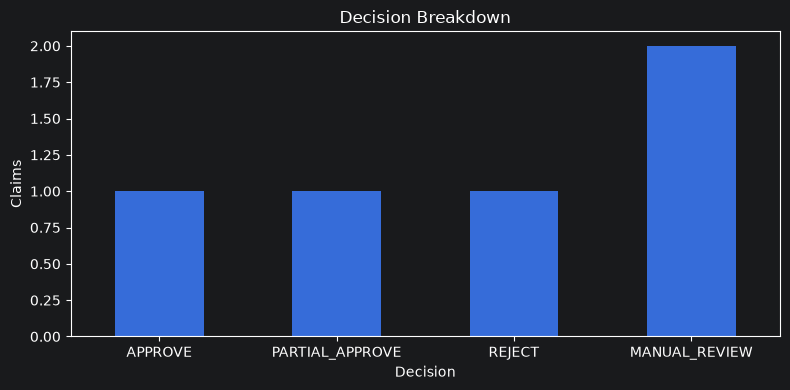

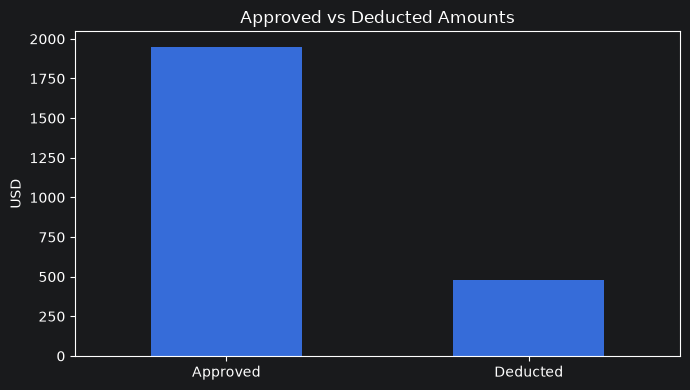

Total claimed:  $ 5650.0
Total approved: $ 1950.0
Total deducted: $ 480.0
Manual reviews: 2


In [17]:
decision_counts = (
    results_df["decision"]
    .value_counts()
    .reindex(
        [
            "APPROVE",
            "PARTIAL_APPROVE",
            "REJECT",
            "MANUAL_REVIEW",
        ],
        fill_value=0,
    )
)

plt.figure(figsize=(8, 4))
decision_counts.plot(kind="bar")
plt.title("Decision Breakdown")
plt.xlabel("Decision")
plt.ylabel("Claims")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

amounts = pd.Series({
    "Approved": results_df["approved_amount"].sum(),
    "Deducted": results_df["deducted_amount"].sum(),
})

plt.figure(figsize=(7, 4))
amounts.plot(kind="bar")
plt.title("Approved vs Deducted Amounts")
plt.ylabel("USD")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

total_claimed = sum(
    sum(float(item["amount"]) for item in claim["items"])
    for claim in claims
)

print("Total claimed:  $", round(total_claimed, 2))
print("Total approved: $", round(results_df["approved_amount"].sum(), 2))
print("Total deducted: $", round(results_df["deducted_amount"].sum(), 2))
print(
    "Manual reviews:",
    int((results_df["decision"] == "MANUAL_REVIEW").sum())
)


## Sample outputs


In [18]:
for result in raw_results[:3]:
    print(json.dumps(result, indent=2))
    print("-" * 80)


{
  "claim_id": "CLM-001",
  "decision": "APPROVE",
  "approved_amount": 1110.0,
  "deducted_amount": 0.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-AIR-01",
    "POL-APR-01",
    "POL-APR-02",
    "POL-APR-03",
    "POL-CAT-01",
    "POL-CAT-02",
    "POL-PD-01",
    "POL-PD-02",
    "POL-RCT-01",
    "POL-RCT-02",
    "POL-TIME-01"
  ],
  "confidence": 0.97,
  "explanation": "All four line items fall within eligible categories (economy airfare, lodging, meals, conference fees) under POL-CAT-01. Receipts are attached for every item, including airfare and lodging, which always require receipts (POL-RCT-01); no missing required receipts. Airfare is economy, so no POL-AIR-01 exception applies. Lodging is $180/night, within the $200 nightly cap (POL-PD-02), and meals are $60/day, within the $75 daily cap (POL-PD-01), so the per-diem limit checker reports $0 in deductions. The claim was submitted 2026-06-20, within 30 days of the trip end (2026-06-12), so POL-TIME-01 is satisfied. 

# Design Notes & Reasoning


### How does the agent work?

The agent uses four tools:

- `policy_lookup` – retrieves the relevant reimbursement rules.
- `receipt_completeness_check` – checks whether required receipts are available.
- `per_diem_limit_checker` – checks meals, lodging, and transport limits.
- `approval_threshold_checker` – checks whether the claim is within the approval limit.

The results from these tools are given to OpenCode Go, which combines the information and produces the final reimbursement decision.

### Why use Python for calculations?

Calculations such as reimbursement limits, deductions, and approval thresholds are handled by Python. This makes the results consistent and avoids relying on the LLM for simple calculations.

### Manual Review

If a claim has missing documents, exceeds an approval limit, contains a policy exception, or has unclear information, the system routes it to `MANUAL_REVIEW` instead of forcing an automatic decision.

### Overall flow

The process is:

**Claim → Policy & Tool Checks → LLM Reasoning → Validation → Final Decision**


# Future Improvements

In the future, this project could be improved by:

- Connecting the policy rules to a real database or document store instead of keeping them in the code.
- Using OCR to automatically read and verify receipts.
- Adding duplicate claim detection to identify repeated submissions.
- Providing a web form or REST API for employees to submit claims directly.
- Adding a simple interface for finance teams to handle `MANUAL_REVIEW` cases.
- Adding more reporting and monitoring to understand common rejection reasons and claim trends.
- Allowing the LLM to dynamically select the tools it needs instead of running the checks in a fixed sequence.
- Adding stronger security, authentication, and automated testing before using the system in production.

## CSV intake demonstration


In [32]:
rows = []

for claim in claims:
    for item in claim["items"]:
        rows.append({
            "claim_id": claim["claim_id"],
            "employee": claim["employee"],
            "trip_start": claim["trip_start"],
            "trip_end": claim["trip_end"],
            "submitted": claim["submitted"],
            "business_purpose": claim["business_purpose"],
            "category": item["category"],
            "description": item["description"],
            "amount": item["amount"],
            "receipt_attached": item["receipt_attached"],
            "nights": item.get("nights"),
            "days": item.get("days"),
            "airfare_class": item.get("airfare_class"),
        })

csv_text = pd.DataFrame(rows).to_csv(index=False)
csv_claims = claims_from_csv(csv_text)

print(
    "CSV round-trip claims:",
    [c["claim_id"] for c in csv_claims]
)


CSV round-trip claims: ['CLM-001', 'CLM-002', 'CLM-003', 'CLM-004', 'CLM-005']


# Final structured results


It outputs a JSON array with one object per supplied claim and exactly the required fields:
`claim_id`, `decision`, `approved_amount`, `deducted_amount`, `missing_docs`, `policy_refs`, `confidence`, `explanation`, `tools_used`.


In [33]:
# FINAL CODE CELL
final_results = [
    {key: result[key] for key in RESULT_KEYS}
    for result in raw_results
]

print(json.dumps(final_results, indent=2))


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-01",
      "POL-APR-02",
      "POL-APR-03",
      "POL-CAT-01",
      "POL-CAT-02",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01",
      "POL-RCT-02",
      "POL-TIME-01"
    ],
    "confidence": 0.98,
    "explanation": "The claim is fully compliant. All four items fall within eligible categories per POL-CAT-01 (economy airfare, lodging, meals, conference fees). All required receipts are attached per POL-RCT-01, with no missing receipts flagged by the receipt_completeness_check tool. Meals ($60/day for 3 days) are under the $75/day cap per POL-PD-01, and lodging ($180/night for 2 nights) is under the $200/night cap per POL-PD-02, resulting in zero limit deductions. Airfare is economy per POL-AIR-01, and the claim was submitted 8 days after trip end, within the 30-day window per